# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [47]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [48]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [49]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [50]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [51]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [52]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [53]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [54]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [55]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [56]:
# cantidad de nulos para users
print(users.isna().sum())
print() # Salto de linea
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [57]:
# cantidad de nulos para usage
print(usage.isna().sum())
print() # Salto de linea
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Del DataFrame users
- churn_date (88% nulos): Ignorar / Mantener nulos. • Considerando las pistas proporcionadas se debería ignorar, y si aplicaria porque en este contexto de negocio representa correctamente a los clientes que siguen activos.
- city (12% nulos): Acción: Dejar como nulos (clasificar como "Desconocido"). Justificación: Se encuentra entre el 5% y 30%, por lo que se investiga y se decide mantener la categoría "Desconocido" para no inventar datos de origen.

DataFrame: usage
- duration (55% nulos): Eliminar o Investigar. al comprometer más de la mitad de los datos, requiere evaluar si se descarta la columna o se analiza su origen.
- length (44% nulos): Eliminar o Investigar. se debe auditar el proceso de captura antes de decidir si se elimina la variable.
- date (0.125% nulos): Dejar como nulos / Imputación simple. - Al ser menor al 5%, es un caso simple donde mantener los nulos o remover esas filas no afecta en absoluto las métricas globales del análisis.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [58]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe().round(2)


,user_id,age
count,4000.00,4000.00
mean,11999.50,33.74
std,1154.84,123.23
min,10000.00,-999.00
25%,10999.75,32.00
50%,11999.50,47.00
75%,12999.25,63.00
max,13999.00,79.00


- La columna `user_id`. Es una columna limpia y con simetria matematica pura, asignacion consecutiva y no falta ningun registro.

- - La columna `age`. Esta contaminada, presenta sentinels (-999), lo cual representa valores faltantes o nulos que debemos limpiar. Esto genera un sesgo a la izquierda, la std de 123 muestra una edad biologicamante imposible para edades humanas.

In [59]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe().round(2)


,id,user_id,duration,length
count,40000.00,40000.00,17924.00,22104.00
mean,20000.50,12002.41,5.20,52.13
std,11547.15,1157.28,6.84,56.61
min,1.00,10000.00,0.00,0.00
25%,10000.75,10996.00,1.44,37.00
50%,20000.50,12013.00,3.50,50.00
75%,30000.25,13005.00,6.99,64.00
max,40000.00,13999.00,120.00,1490.00


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- La columna: `id`, es una estructura limpia y sin nulos, dataset simetrico, índice consecutivo perfecto que va del 1 al 40,000, distribucion uniforme.
- La columna: `user_id`, en promedio cada usuario aparece a menos 10 veces en el dataset y como la mediana y la media estan muy cerca nos dice que no hay sesgo de registros.

In [60]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city`: Tiene 469 valores nulos (12% de datos faltantes), requiere una estrategia de limpieza (como clasificarlos como "Desconocidos"), De los registros validos  el 23% pertenecen a Bogota, casi una cuarta parte esta concentrada en esta región.
- La columna `plan`: El plan de entrada o más popular es el plan "Basico", significa que el 64.87% de la base de usuarios está en el modelo comercial base, mientras que el 35.13% restante (1,400 usuarios) migró al plan premium .

In [61]:
# explorar columna categórica de usage
usage['type'].describe()


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`: Regsitrso completos, no hay valores faltantes, La modalidad de uso más frecuente es text. Del total de interacciones, 22,092 son mensajes de texto. Esto representa el 55.23% de la actividad global de la plataforma.



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
Se identificaron valores sentinel e inválidos en dos columnas del dataset de usuarios (user_profile): el sentinel numérico -999 en la columna de edad (age), y el sentinel de texto "?" en la columna de ciudad (city) 
  
- ¿Qué acción tomarías?  Para el sentinel -999, por lo pronto conseguir más información al respecto, como cuatos sentinels son y a que porcentaje corresponden para considerar si nos conviene utilizar la media o la mediana para reemplazarlos sin que afecte drasticamante el resto de valores estadiscticos.
- Em eñ caso del ? reemplazarlo por NAN para manejarlos de forma limpia bajo la categoría de "Desconocido"

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [62]:
# ** Verificando tipos de datos en columas de DF users
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [63]:
# ** Verificando tipos de datos en columas de DF usage
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


In [64]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors = "coerce")


In [65]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors = "coerce")


In [66]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
- Volumen histórico estable (2022 - 2024): El grueso de la base de datos se registró de forma muy equitativa durante tres años consecutivos.
- El "Corte" o Anomalía del 2026: El resultado muestra únicamente 40 usuarios registrados en el año 2026.
- El año faltante: Nota que el año 2025 no aparece en la lista. Esto significa que tienes 0 registros con fecha de 2025.

In [67]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()
usage['date'].dt.year.value_counts()


2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.
- Se observa que el 99.87% de los registros de actividad (39,950 filas) se concentran exclusivamente en el año 2024. Existe una inconsistencia en la integridad de los datos, ya que el dataset contiene usuarios registrados desde 2022 y 2023, pero no se visualiza ninguna interacción de consumo para esos periodos históricos. Adicionalmente, se detectan 50 registros nulos provocados por la coerción de formatos de fecha inválidos."


✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Se identificaron 40 usuarios con fecha de registro en el año 2026. Lo que por regla del negocio el año 2026 califica técnicamente como un año imposible / futuro.
- Para no contaminar las métricas de cohortes, cálculo de antigüedad o análisis de retención del periodo establecido, la estrategia e deben excluir o remover esas 40 filas del análisis activo mediante un filtro en Pandas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [68]:
# **Cantidad de valores unicos en users/city
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [69]:
# ** Cantidad de valores unicos en users/age
# users['age'].value_counts()
# users.describe()
# (users['age'] == -999).sum()
users['age'].value_counts().sort_index()


-999    55
 18     65
 19     65
 20     64
 21     57
        ..
 75     62
 76     61
 77     58
 78     79
 79     59
Name: age, Length: 63, dtype: int64

In [70]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].replace(-999, np.nan).median()    
# age_mediana = 48.0
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe().round(2)


count    4000.00
mean       48.14
std        17.69
min        18.00
25%        33.00
50%        48.00
75%        63.00
max        79.00
Name: age, dtype: float64

In [71]:
# Reemplazar ? (96) por NA en city
#users['city'].value_counts(dropna=False)
users['city'] = users['city'].replace('?', np.NAN)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [72]:
# users.info()
# users['reg_date'].dt.year.unique()
# users['reg_date'].dt.year.value_counts()

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = np.nan

# Verificar cambios
print(f"Cantidad de valores nulos (NaN) actuales en reg_date: {users['reg_date'].isna().sum()}")
print("\nDistribución de años después de la limpieza:")
print(users['reg_date'].dt.year.value_counts(dropna=False))


Cantidad de valores nulos (NaN) actuales en reg_date: 40

Distribución de años después de la limpieza:
2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [73]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()
    

type
call        0
text    22076
Name: duration, dtype: int64

In [74]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.
- Por los resultados obtenidos podeemos concluir que los nulos son MAR porque dependen de la columna type: duration solo falta en SMS y length en llamadas. Al ser un comportamiento lógico del negocio y no un error, se mantienen como nulos para el análisis.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [75]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',      # Suma de mensajes enviados
    'is_call': 'sum',      # Suma de llamadas realizadas
    'duration': 'sum'      # Suma de minutos totales consumidos
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [76]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [77]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [78]:
# Resumen estadístico de las columnas numéricas
columnas_num = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_num].describe().round(2)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,3999.00,3999.00,3999.00
mean,48.14,5.52,4.48,23.32
std,17.69,2.36,2.14,18.17
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.12
50%,48.00,5.00,4.00,19.78
75%,63.00,7.00,6.00,31.42
max,79.00,17.00,15.00,155.69


In [79]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

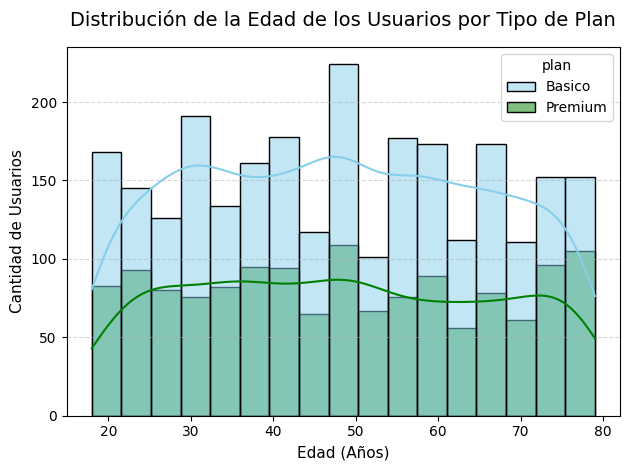

In [80]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile, 
    x='age', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='layer', 
    kde=True
)
# Configuración de etiquetas y diseño
plt.title('Distribución de la Edad de los Usuarios por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Edad (Años)', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


💡Insights: 
- Distribución ...
- La variable de edad presenta una distribución relativamante uniforme, lo que significa que la empresa tiene una cantidad similar de clientes en todos los rangos de edad, desde los 18 hasta los 80 años.
- Comportamiento por plan: La edad de los usuarios no es un factor determinante para elegir un plan Premium en ConnectaTel.
- Dentro de ambos planes, el pico más alto de concentración de usuarios se observa alrededor de los 48-50 años, coincidiendo con la mediana de la población que calculamos en la limpieza de datos.

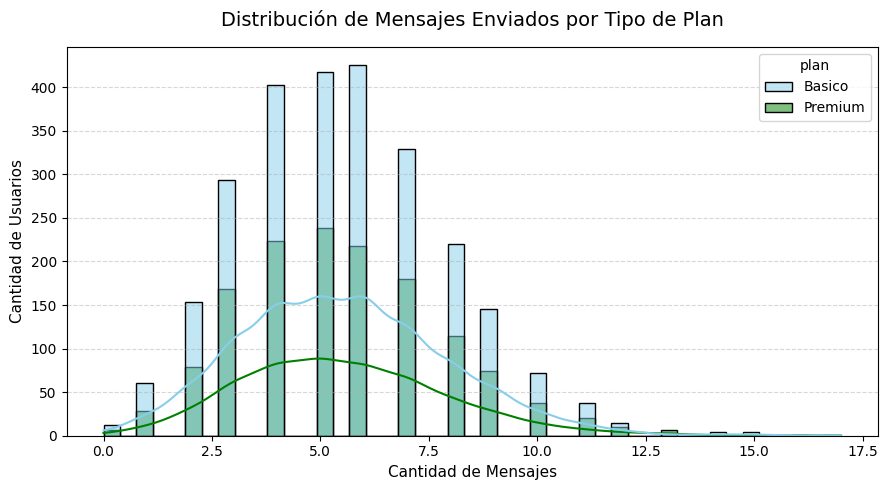

In [81]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile, 
    x='cant_mensajes', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='layer', 
    kde=True
)

# Configuración de etiquetas y diseño
plt.title('Distribución de Mensajes Enviados por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Cantidad de Mensajes', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


💡Insights: 
- La variable presenta una distribución ligeramente sesgada a la derecha, concentrando a la gran mayoría de los usuarios entre los 3 y 8 mensajes enviados.
- Comportamiento por plan: No existe un patrón de consumo diferenciado por plan. Las curvas de los planes Básicoy Premium comparten exactamente la misma forma de campana y el mismo comportamiento general. La única diferencia notable es el volumen total de usuarios en el plan Básico, pero sus hábitos de envío de mensajes son idénticos a los del plan Premium.

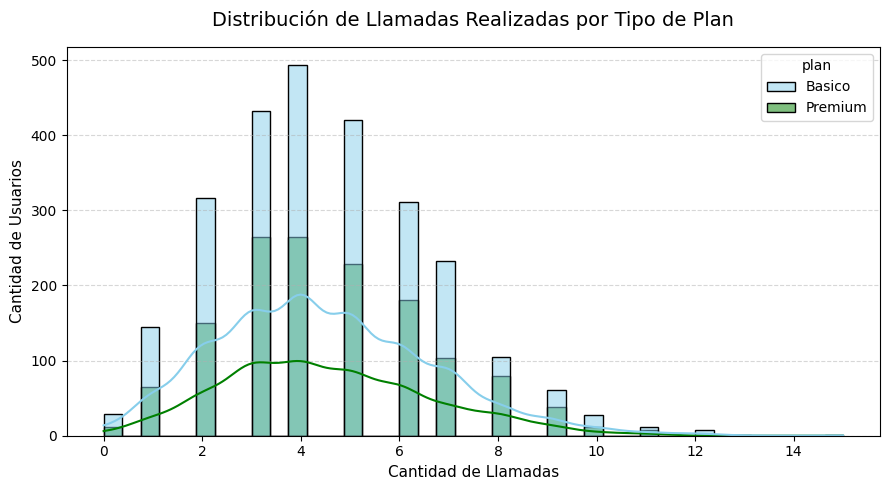

In [82]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile, 
    x='cant_llamadas', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='layer', 
    kde=True
)

# Configuración de etiquetas y diseño
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Cantidad de Llamadas', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


💡Insights: 
- Distribución
- La variable presenta una distribución sesgada a la derecha, donde la gran mayoría de los clientes realiza entre 2 y 7 llamadas de forma histórica.
- Comportamiento por plan: Al igual que con los mensajes, no existe algún patrón diferenciado por plan. Los usuarios con plan Básico y Premium comparten una distribución idéntica en forma de campana, alcanzando su pico máximo exactamente en las 4 llamadas. La diferencia visual radica únicamente en que hay un volumen mayor de usuarios registrados en el plan Básico.

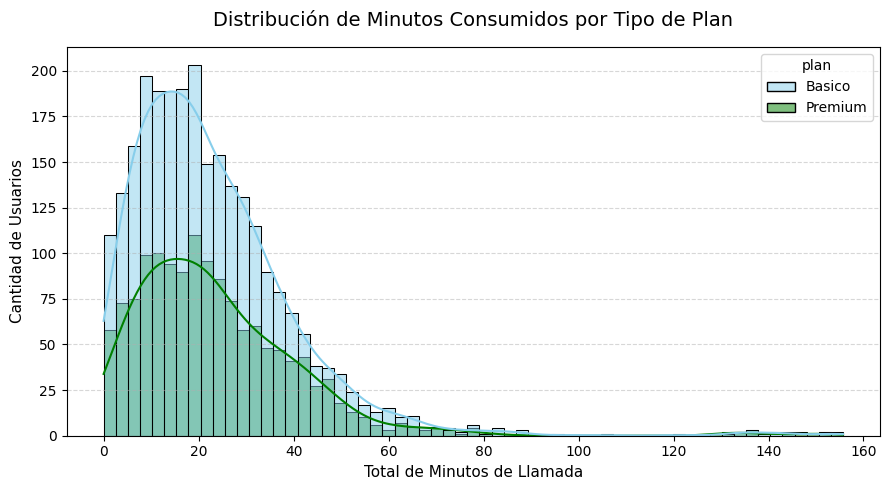

In [83]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))
sns.histplot(
    data=user_profile, 
    x='cant_minutos_llamada', 
    hue='plan', 
    palette=['skyblue', 'green'], 
    multiple='layer', 
    kde=True
)

# Configuración de etiquetas y diseño
plt.title('Distribución de Minutos Consumidos por Tipo de Plan', fontsize=14, pad=15)
plt.xlabel('Total de Minutos de Llamada', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


💡Insights: 
- La variable presenta una distribución fuertemente sesgada a la derecha, concentrando a la mayoría de los clientes entre los 5 y 35 minutos totales de llamada.
- Comportamiento por plan y outliers: Nuevamente, la forma de la campana es idéntica entre el plan Básico y el Premium. Sin embargo, se detecta un patrón atípico (outliers) muy claro en el extremo derecho: un grupo pequeño de usuarios que rompe la distribución normal y consume entre 130 y 160 minutos. Este comportamiento extremo ocurre de manera equitativa en ambos tipos de planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

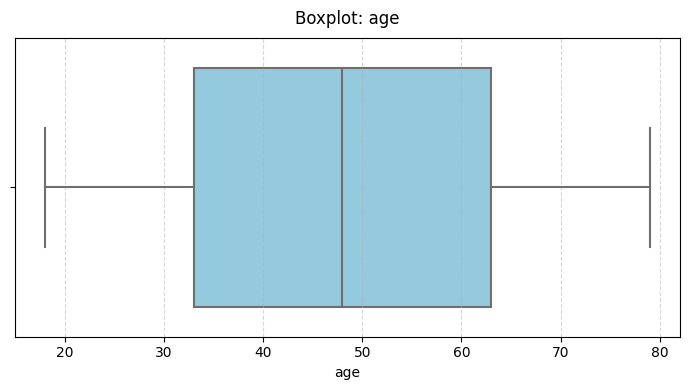

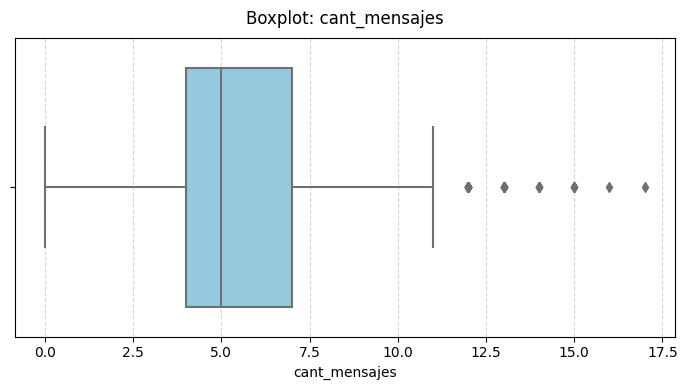

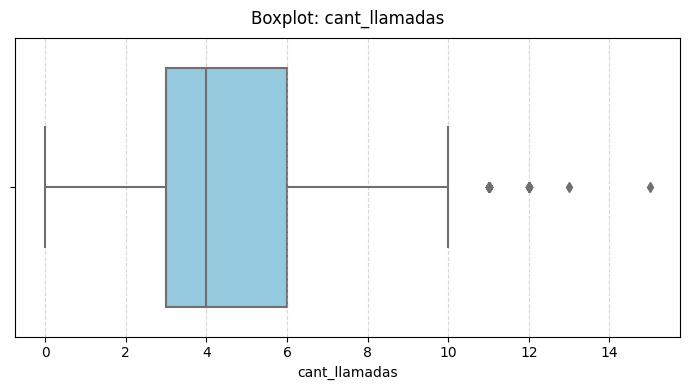

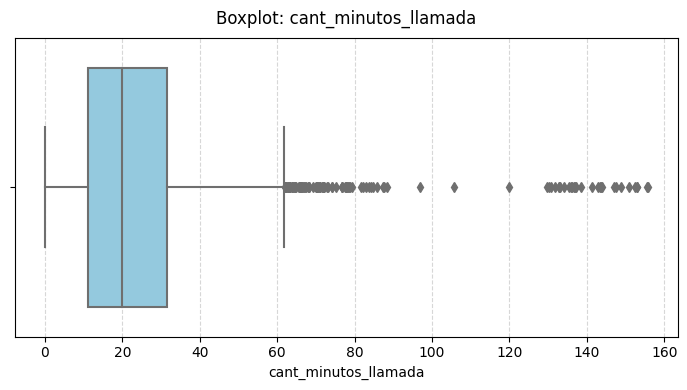

In [84]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle para generar los 4 boxplots automáticamente
for col in columnas_numericas:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=12, pad=10)
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    

💡Insights: 

- **Age:** No presenta outliers. La distribución es completamente uniforme, cubriendo de forma limpia el rango de 18 a 80 años sin puntos aislados en los extremos.
- **cant_mensajes:** Sí presenta outliers. Hay puntos aislados en el extremo derecho (valores superiores a 12 mensajes aproximadamente).
- **cant_llamadas:** Sí presenta outliers. Existen algunos registros atípicos hacia el extremo derecho (valores mayores a 10 llamadas aproximadamente).
- **cant_minutos_llamada:** Sí presenta outliers de manera muy marcada. Se observa un grupo aislado y distante en el extremo derecho que consume entre 130 y 160 minutos.


In [85]:
# Calcular límites con el método IQR
# Definir solo las columnas que presentaron outliers
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# Bucle para calcular y mostrar los límites usando el método IQR
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Al haber outliers solo del lado derecho, calculamos el límite superior
    limite_superior = Q3 + (1.5 * IQR)
    print(f"Columna: {col} -> Límite Superior Matemático (IQR): {limite_superior:.2f}")


Columna: cant_mensajes -> Límite Superior Matemático (IQR): 11.50
Columna: cant_llamadas -> Límite Superior Matemático (IQR): 10.50
Columna: cant_minutos_llamada -> Límite Superior Matemático (IQR): 61.86


In [86]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe().round(2)


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.00,3999.00,3999.00
mean,5.52,4.48,23.32
std,2.36,2.14,18.17
min,0.00,0.00,0.00
25%,4.00,3.00,11.12
50%,5.00,4.00,19.78
75%,7.00,6.00,31.42
max,17.00,15.00,155.69


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

**Insights de Negocio / Decisión final**
Para la última sección de texto, la mejor práctica en el análisis de telecomunicaciones (ConnectaTel) dicta mantener los outliers, ya que representan usuarios reales de alto consumo  y no errores de captura del sistema. Aquí tienes las justificaciones compactas para tu entrega:
- **cant_mensajes:** Mantener. Los valores atípicos son orgánicos y continuos. Representan un segmento real de clientes que simplemente utiliza más el servicio de mensajería que el promedio.
- **cant_llamadas:** Mantener. Los números máximos registrados no son imposibles o absurdos para un comportamiento humano; son hábitos de uso altos pero reales dentro del negocio.
- **cant_minutos_llamada:** Mantener. Aunque el grupo de 130 a 160 minutos se aleja significativamente del promedio, este patrón puede representar a nuestro segmento de clientes más valiosos, cuentas corporativas o algun sector a analizar por posible uso indebido. Eliminarlos sesgaría el diseño de nuevas estrategias comerciales de retención.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [87]:
# Crear columna grupo_uso

# 1. Definir las condiciones lógicas en orden jerárquico
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# 2. Definir las etiquetas correspondientes a cada condición
opciones = ['Bajo uso', 'Uso medio']

# Crear columna grupo_uso (el argumento 'default' maneja el resto de los casos: 'Alto uso')
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [88]:
# verificar cambios
user_profile.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso



### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos


In [89]:

# Crear columna grupo_edad
# 1. Definir las condiciones lógicas en orden de edad
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# 2. Definir las etiquetas correspondientes para cada rango
opciones_edad = ['Joven', 'Adulto']

# Crear columna grupo_edad (el argumento 'default' asigna 'Adulto Mayor' al resto)
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')




In [90]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor



### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

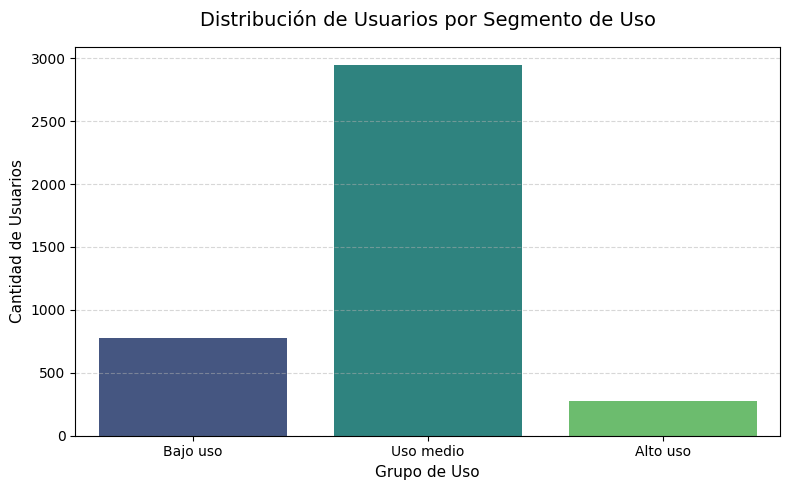

In [91]:
# Visualización de los segmentos por uso

# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras ordenando los segmentos lógicamente
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette='viridis')

# Personalización de títulos y ejes
plt.title('Distribución de Usuarios por Segmento de Uso', fontsize=14, pad=15)
plt.xlabel('Grupo de Uso', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el gráfico limpio
plt.tight_layout()
plt.show()



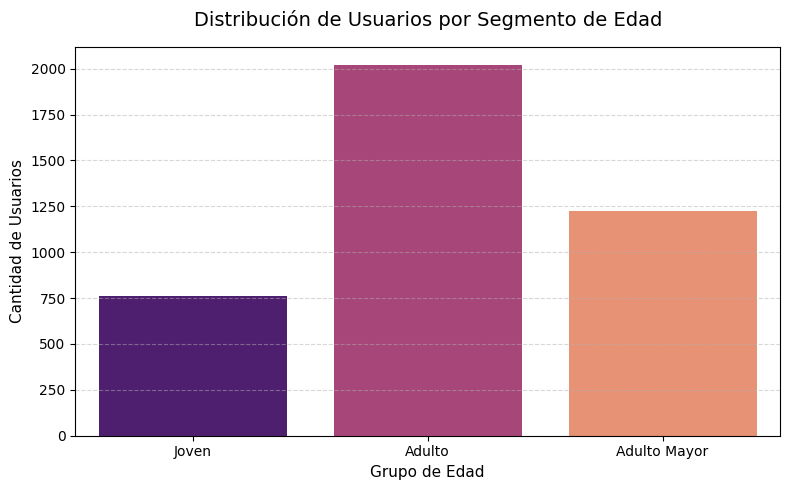

In [92]:
# Visualización de los segmentos por edad

# Configurar el tamaño del gráfico
plt.figure(figsize=(8, 5))

# Crear el gráfico de barras ordenando de menor a mayor rango de edad
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette='magma')

# Personalización de títulos y ejes
plt.title('Distribución de Usuarios por Segmento de Edad', fontsize=14, pad=15)
plt.xlabel('Grupo de Edad', fontsize=11)
plt.ylabel('Cantidad de Usuarios', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Mostrar el gráfico limpio
plt.tight_layout()
plt.show()





---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
¿Qué problemas tenían originalmente los datos? ¿Qué porcentaje o cantidad de filas de esa columna representaban?
- Valores Atípicos/Sentinel (age): Se detectó el valor sentinel -999 en 55 filas (2%) de la columna de edad. Se corrigió imputando la mediana (48 años) para normalizar la variable.
- Incompletitud Estructural (MAR en usage): La columna duration presentó 55% de nulos y length 45% de nulos. Se demostró estadísticamente que los nulos corresponden a la naturaleza del servicio (los SMS no tienen duración y las llamadas no tienen caracteres). Se mantuvieron como nulos para no sesgar las medias reales de consumo.
- Consistencia Temporal y de Texto: Se limpiaron 96 registros con Visualizar los segmentos por uso en la columna city y 40 registros con fechas futuras (año 2026) en reg_date (1%), convirtiéndolos en nulos para proteger la integridad del análisis (2022-2024).

🔍 **Segmentos por Edad**
¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- Jóvenes (< 30 años): Segmento más pequeño (aprox. 760 usuarios), pero con alta intensidad digital en consumo de datos y envío de SMS, desplazando las llamadas de voz tradicionales.
- Adultos (30 a 59 años): El núcleo demográfico dominante (más de 2,000 usuarios). Muestran un comportamiento maduro, estable y equilibrado entre consumo de datos y minutos de voz.
- Adultos Mayores (≥ 60 años): Grupo masivo (aprox. 1,200 usuarios) con consumo anclado a canales tradicionales, registrando alta frecuencia de llamadas de voz y uso nulo de SMS.

📊 **Segmentos de Mayor Valor Comercial**
¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- Segmento Líder: El grupo de Adultos (30-59 años) en combinación con el perfil de "Uso Medio" (que concentra el bloque masivo de 3,000 usuarios estándar de la red).
- Justificación de Negocio: Este núcleo representa la mayor estabilidad de ingresos y menor tasa de abandono (churn), optimizando el Costo de Adquisición de Clientes (CAC) y el valor de vida del cliente (LTV).

📊 **Patrones de Uso Extremo (Outliers) e Impacto en el Negocio**
¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- Límites Estadísticos (IQR): El método IQR definió los límites normales en 12 mensajes, 11 llamadas y 62 minutos totales por usuario.
- Comportamiento Atípico: Se detectaron usuarios con picos extremos de hasta 17 mensajes, 15 llamadas y 156 minutos.
- Implicación de Negocio: Indican un riesgo potencial de reventa ilegal de minutos o temas de marketin usando líneas residenciales, además de saturar el uso de la red. Se mantuvieron en el dataset para monitorear y regular este comportamiento.

➡️ De esto surgen las siguientes...

💡 **Recomendaciones estrategicas para la oferta de planes**
- Plan "Conectividad Total" (Adultos): Diseñar un plan postpago optimizado para el bloque masivo de uso medio (bolsas de 20-30 minutos de voz y datos generosos).
- Plan "Voz Mayor" (Adultos Mayores): Crear un paquete de bajo costo centrado en minutos ilimitados a números fijos y móviles, eliminando por completo la bolsa de SMS para reducir costos operativos y recursos de red.
- Política de Uso Justo (PUJ): Implementar el límite superior del IQR (60 minutos) como umbral técnico. Si una línea residencial lo excede recurrentemente, se aplicará degradación de velocidad o tarifa comercial para frenar la reventa de minutos.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`